## Development and Evaluation Based Natural Language Processing Model for Sentiment Expressed in Brand and Products Emotions

### Project Overview

This project develops and evaluates a Natural Language Processing (NLP) model to analyze sentiment expressed in Twitter conversations about technology brands and products, with a primary focus on Apple and Google

The project combines exploratory data analysis, text preprocessing, feature engineering, machine learning classification, and model interpretability techniques to transform unstructured tweet data into actionable insights.

### Business Problem 

Organizations rely on social media data to understand customer experiences and brand perception, but the large volume of online conversations makes manual analysis difficult.

This project addresses the challenge of automatically identifying sentiment expressed toward brands and products, enabling organizations to Monitor brand reputation, detect customer dissatisfaction early,iIdentify common product issues,measure public perception,support customer experience improvement initiatives, Inform product development and marketing strategies.

### Main Objectives

To develop and evaluate a Natural Language Processing model for 
sentiments expressed in brand and products Emotions.

**Specific objectives**

To determine the extent to which tweet content reflects sentiment

To assess the distribution of sentiment across tweets based on the brands mentioned within the tweet text

To analyze the distribution of target subcategories represented within tweet content

To examine the influence of tweet content and sentiment on target categories

To analyze customer complaints expressed in tweets toward specific brand products


**Research Questions**

1. To what extent does tweet content reflect sentiment?

2. How is sentiment distributed across tweets based on the brands mentioned within the tweet text?

3. What is the distribution of target subcategories represented within tweet content?

4. How do tweet content and sentiment influence target categories?

5. What are customer complaints expressed in tweets toward specific brand products?

**Stakeholders**

Apple Inc. , Google, Customers

**Sources of Data**

 CrowdFlower Twitter Sentiment Datase, 2013

- Loading libraries

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import html
import unicodedata
import contractions

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from lime.lime_text import LimeTextExplainer
from collections import defaultdict

# Download NLTK data (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

- load dataset

In [3]:
df = pd.read_csv('tweet_sentiment.csv', encoding='latin-1')

- Data Inspection

In [4]:
# Display first few rows
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [5]:
# Check dataset shape
df.shape

(9093, 3)

9,093 rows (tweets)

3 columns (features)

In [6]:
list(df.columns) # Column names

['tweet_text',
 'emotion_in_tweet_is_directed_at',
 'is_there_an_emotion_directed_at_a_brand_or_product']

In [7]:
df = df.rename(columns={
    'tweet_text': 'Tweet',
    'emotion_in_tweet_is_directed_at': 'Target',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'Sentiment'
})


In [8]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet      9092 non-null   object
 1   Target     3291 non-null   object
 2   Sentiment  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


- Summary of dataset

Total rows: 9,093

Columns: 3 (Tweet, Target, Sentiment)

Data type: all object (text/categorical)

In [9]:
# Checking Missing value
df.isnull().sum()

Tweet           1
Target       5802
Sentiment       0
dtype: int64

### Inspection per columns

#### Tweet Column

In [10]:
# Check Tweet distribution
df['Tweet'].value_counts().head()

Tweet
RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #sxsw    5
RT @mention Google to Launch Major New Social Network Called Circles, Possibly Today {link} #sxsw                 4
RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #SXSW    4
RT @mention Google to Launch Major New Social Network Called Circles, Possibly Today {link} #SXSW                 3
RT @mention ÷¼ GO BEYOND BORDERS! ÷_ {link} ã_ #edchat #musedchat #sxsw #sxswi #classical #newTwitter          2
Name: count, dtype: int64

In [11]:
# Inspection of a random sample of 5 tweets
df['Tweet'].sample(5, random_state=42) 

5558    RT @mention best thing abt @mention for #SXSW?...
8350    Gary is starting a new show &quot;Daily Grape&...
2303    The walk by Lady Bird Lake was lovely, but Goo...
927     C34: ItÛªs Not a Retreat! {link} [codes valid...
1963    Holler Gram for iPad on the iTunes App Store: ...
Name: Tweet, dtype: object

In [12]:
# Count total duplicate tweets (excluding first occurrence)
df.duplicated(subset=['Tweet']).sum()

27

In [13]:
# Percentage of rows that are duplicates
(df.duplicated(subset=['Tweet']).sum() / len(df)) * 100

0.29693170570768723

In [14]:
# See all duplicate tweet rows
df[df.duplicated(subset=['Tweet'], keep=False)].sort_values('Tweet').head(10)

,Tweet,Target,Sentiment
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
3962,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
466,"Before It Even Begins, Apple Wins #SXSW {link}",Apple,Positive emotion
468,"Before It Even Begins, Apple Wins #SXSW {link}",Apple,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion
2559,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion
774,Google to Launch Major New Social Network Call...,NaN,No emotion toward brand or product
776,Google to Launch Major New Social Network Call...,NaN,No emotion toward brand or product
17,I just noticed DST is coming this weekend. How...,iPhone,Negative emotion
8483,I just noticed DST is coming this weekend. How...,iPhone,Negative emotion


In [15]:
# Exact duplicate rows (all columns identical)
df.duplicated().sum()

22

In [16]:
# Find tweets that appear multiple times with different Target/Sentiment
duplicate_tweets = df[df.duplicated(subset=['Tweet'], keep=False)]

inconsistent = duplicate_tweets.groupby('Tweet').filter(
    lambda x: x['Target'].nunique() > 1 or x['Sentiment'].nunique() > 1
)

inconsistent[['Tweet', 'Target', 'Sentiment']].head(10)

,Tweet,Target,Sentiment
3811,Win free ipad 2 from webdoc.com #sxsw RT,NaN,No emotion toward brand or product
3812,Win free iPad 2 from webdoc.com #sxsw RT,NaN,No emotion toward brand or product
3813,Win free ipad 2 from webdoc.com #sxsw RT,iPad,Positive emotion
3814,Win free iPad 2 from webdoc.com #sxsw RT,iPad,Positive emotion
6292,RT @mention Marissa Mayer: Google Will Connect...,Google,Positive emotion
6293,RT @mention Marissa Mayer: Google Will Connect...,Google,Positive emotion
6294,RT @mention Marissa Mayer: Google Will Connect...,NaN,No emotion toward brand or product
6295,RT @mention Marissa Mayer: Google Will Connect...,NaN,No emotion toward brand or product
6296,RT @mention Marissa Mayer: Google Will Connect...,Google,Positive emotion
6297,RT @mention Marissa Mayer: Google Will Connect...,NaN,No emotion toward brand or product


In [17]:
# Remove duplicate tweets, keeping first occurrence
df = df.drop_duplicates(subset=['Tweet'], keep='first')

- Target Column

In [18]:
# Fill missing values first
df['Target'] = df['Target'].fillna('No specific brand')

# Standardize existing categories
df['Target'] = df['Target'].replace({
    'iPad or iPhone App': 'Apple App',
    'Android App': 'Android',
    'Other Google product or service': 'Google',
    'Other Apple product or service': 'Apple'
})


In [19]:
# To remove leading and trailing whitespace

df['Target'] = df['Target'].str.strip()

In [20]:
# See unique Target
df['Target'].unique()

array(['iPhone', 'Apple App', 'iPad', 'Google', 'No specific brand',
       'Android', 'Apple'], dtype=object)

In [21]:
# Include missing values
df['Target'].value_counts(dropna=False)

Target
No specific brand    5786
iPad                  943
Google                721
Apple                 694
Apple App             469
iPhone                296
Android               157
Name: count, dtype: int64

In [22]:
# See what sentiment the 'No specific brand' tweets have
df[df['Target'] == 'No specific brand']['Sentiment'].value_counts()

Sentiment
No emotion toward brand or product    5282
Positive emotion                       306
I can't tell                           147
Negative emotion                        51
Name: count, dtype: int64

- Sentiment Column

In [23]:
# unique Sentiment
df['Sentiment'].unique()

array(['Negative emotion', 'Positive emotion',
       'No emotion toward brand or product', "I can't tell"], dtype=object)

In [24]:
# Check sentiment distribution
df['Sentiment'].value_counts()

Sentiment
No emotion toward brand or product    5373
Positive emotion                      2968
Negative emotion                       569
I can't tell                           156
Name: count, dtype: int64

In [25]:
# Cross-tabulation to observe pattern
pd.crosstab(df['Sentiment'], df['Target'], normalize='columns') * 100

Target,Android,Apple,Apple App,Google,No specific brand,iPad,iPhone
Sentiment,,,,,,,
I can't tell,0.000000,0.288184,0.000000,0.277393,2.540615,0.424178,0.337838
Negative emotion,10.191083,13.976945,13.432836,15.950069,0.881438,13.255567,34.459459
No emotion toward brand or product,1.273885,3.170029,2.132196,3.328710,91.289319,2.545069,3.040541
Positive emotion,88.535032,82.564841,84.434968,80.443828,5.288628,83.775186,62.162162


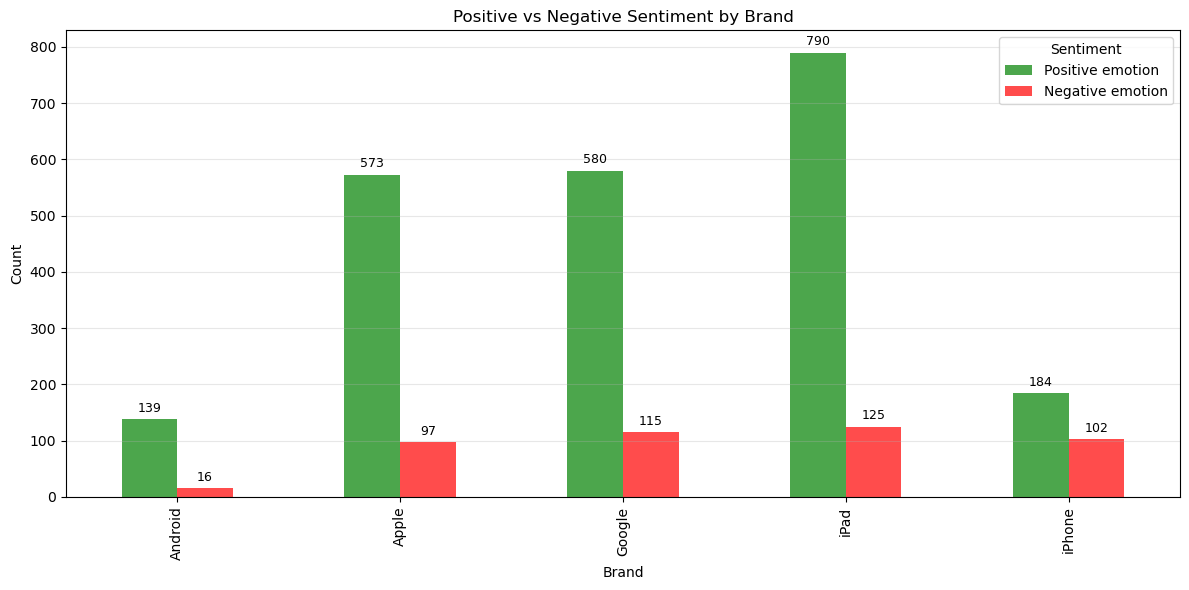

In [26]:
# filter brands and sentiments
brands = ['Android', 'Apple', 'Google', 'iPad', 'iPhone']
sentiments = ['Positive emotion', 'Negative emotion']

# create crosstab
ct = pd.crosstab(df['Target'], df['Sentiment']).loc[brands, sentiments]

# plot
ax = ct.plot(kind='bar', figsize=(12,6), color=['green','red'], alpha=0.7)

# title + labels
ax.set_title('Positive vs Negative Sentiment by Brand')
ax.set_xlabel('Brand')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

# make brand names vertical
plt.xticks(rotation=90)

# add data labels on bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

#### Insight 

- Across every single brand Positive emotions are significantly high than Negative emotions

- With 790 positive mentions against only 125 negative ones, the iPad is both the most talked about product in this dataset and the one with the highest positive-to-negative ratio

- Android has the smallest mentioned in the dataset, with 155 total mentions. However, it also records the lowest level of negative sentiment overall, with only 16 negative mentions


### Overview

#### Univarient Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_32292\3148198725.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


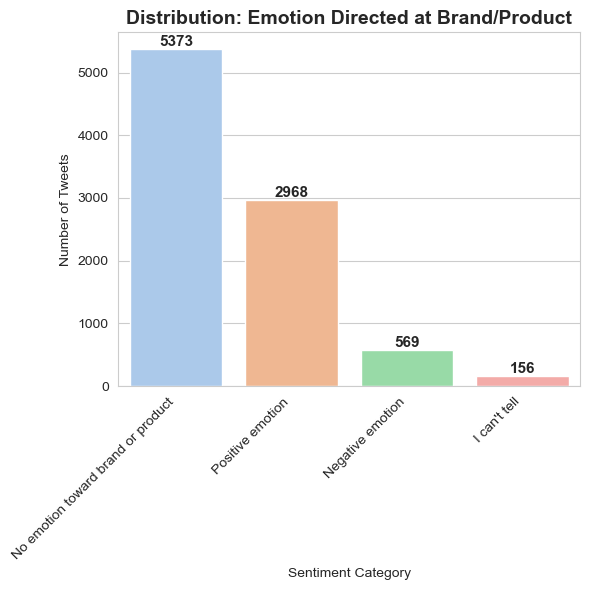

In [27]:
# style
sns.set_style("whitegrid")

# order once (cleaner)
order = df['Sentiment'].value_counts().index

# plot
plt.figure(figsize=(6, 6))
ax = sns.countplot(
    data=df,
    x='Sentiment',
    order=order,
    palette='pastel'
)

# titles and labels
ax.set_title('Distribution: Emotion Directed at Brand/Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Number of Tweets')

# rotate x labels
plt.xticks(rotation=45, ha='right')

# add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### Insight 

- Approximately 59.3% of all tweets were classified as Neutral, indicating that most conversations mention brands or products without expressing strong emotional opinions.

#### Bivariate Analysis

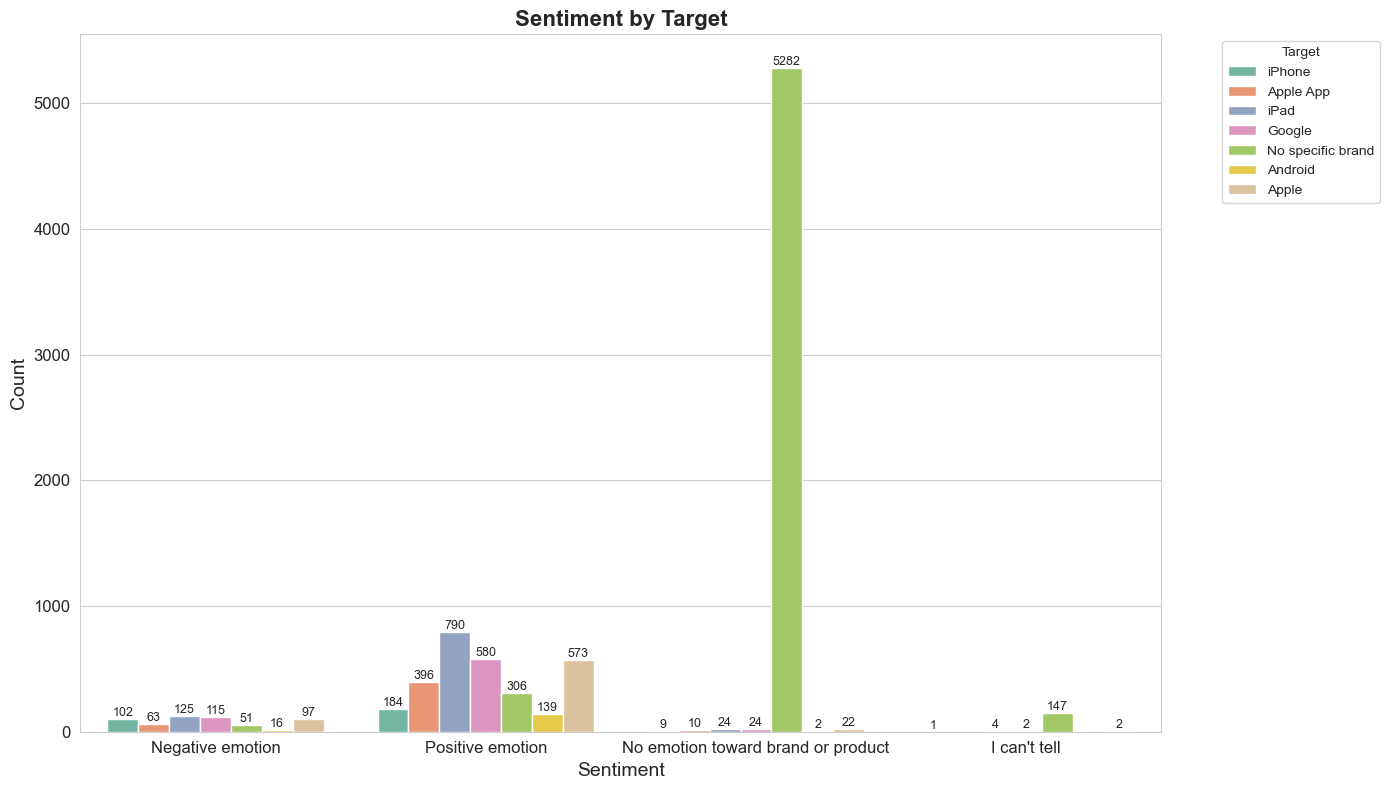

In [28]:
plt.figure(figsize=(14, 8))

ax = sns.countplot(
    data=df,
    x='Sentiment',
    hue='Target',
    palette='Set2'
)

# title + labels
ax.set_title('Sentiment by Target', fontsize=16, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# tick formatting
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

# legend outside plot
ax.legend(
    title='Target',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### Insight 

- Both Apple and Google conversations were predominantly neutral

- Apple generated slightly stronger emotional responses than Google

- Negative sentiment was relatively low across both brands

- Positive sentiment significantly exceeded negative sentiment

#### Multivarient 

In [29]:
# Number of times each sentiment appears for each target
pd.crosstab(df['Target'], df['Sentiment'])

Sentiment,I can't tell,Negative emotion,No emotion toward brand or product,Positive emotion
Target,,,,
Android,0,16,2,139
Apple,2,97,22,573
Apple App,0,63,10,396
Google,2,115,24,580
No specific brand,147,51,5282,306
iPad,4,125,24,790
iPhone,1,102,9,184


#### Insight

-  Strong dominance of "No Specific Brand" discussions

- Product-specific discussions generated more emotional engagement

- Positive sentiment remained dominant among branded conversations

### Data Cleaning 

- Text Preprocessing

In [30]:
# custom stopwords

common_english = {
    'the','be','to','of','and','a','in','that','have','i',
    'it','for','not','on','with','he','as','you','do','at',
    'this','but','his','by','from','they','we','say','her','she',
    'or','an','will','my','one','all','would','there','their',
    'what','so','up','out','if','about','who','get','which','go',
    'me','when','make','can','like','time','just','him','know',
    'take','people','into','year','your','good','some','could','them',
    'see','other','than','then','now','look','only','come','its','over',
    'think','also','back','after','use','two','how','our','work',
    'first','well','way','even','new','want','because','any','these',
    'give','day','most','us','is','was','are','been','has','had',
    'were','may','might','must','shall','should','will','would'
}

tech_words = {
    'iphone','ipad','ipod','mac','imac','macbook','apple','ios',
    'android','google','pixel','nexus','samsung','xiaomi','huawei',
    'oneplus','lg','sony','nokia','blackberry','windows','microsoft',
    'surface','xbox','playstation','nintendo','amazon','alexa','echo',
    'facebook','instagram','twitter','tiktok','snapchat','whatsapp',
    'telegram','signal','discord','reddit','linkedin','youtube',
    'netflix','spotify','uber','lyft','airbnb','paypal','venmo',
    'sxsw','sxswi','retweet','tweet','hashtag','viral','post','share','like'
}

stop_words = set(stopwords.words('english')) | common_english

lemmatizer = WordNetLemmatizer()

# Meaningful word check

def is_meaningful_word(word):
    word = word.lower()

    if len(word) < 3:
        return False

    if not any(c.isalpha() for c in word):
        return False

    if not any(c in "aeiou" for c in word):
        return False

    if re.search(r'[^aeiou]{4,}', word):
        return False

    if re.search(r'(.)\1{2,}', word):
        return False

    # Keep known tech words
    if word in tech_words:
        return True

    # Keep normal words
    return word.isalpha()

# Main Cleaning Function

def clean_text_comprehensive(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove RT
    text = re.sub(r'^RT\s+', '', text, flags=re.IGNORECASE)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Decode HTML entities
    text = html.unescape(text)

    # Normalize unicode
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # Lowercase
    text = text.lower()

    # Remove hashtags symbol only
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    cleaned_words = []
    for w in words:

        # Remove stopwords but keep negation
        if w in stop_words and w not in {"no", "not", "nor", "n't"}:
            continue

        # Meaningful word filter
        if not is_meaningful_word(w):
            continue

        # Lemmatize
        w = lemmatizer.lemmatize(w)

        cleaned_words.append(w)

    return ' '.join(cleaned_words)

# Apply cleaning

df['Cleaned_Tweet'] = df['Tweet'].apply(clean_text_comprehensive)

# Remove empty results
df = df[df['Cleaned_Tweet'].str.len() > 5].copy()

# Optional second pass filter

def clean_meaningful_words(text):
    if pd.isna(text):
        return ""

    return ' '.join([w for w in text.split() if is_meaningful_word(w)])


df['Cleaned_Tweet_Final'] = df['Cleaned_Tweet'].apply(clean_meaningful_words)

# Check results

print("Original:")
print(df['Tweet'].head(3))

print("\nCleaned:")
print(df['Cleaned_Tweet_Final'].head(3))

print("\nDataset size after cleaning:", len(df))

Original:
0    .@wesley83 I have a 3G iPhone. After 3 hrs twe...
1    @jessedee Know about @fludapp ? Awesome iPad/i...
2    @swonderlin Can not wait for #iPad 2 also. The...
Name: Tweet, dtype: object

Cleaned:
0    iphone tweeting riseaustin dead need upgrade p...
1    awesome ipadiphone app youll likely appreciate...
2                                   not wait ipad sale
Name: Cleaned_Tweet_Final, dtype: object

Dataset size after cleaning: 9064


In [31]:
# Save cleaned dataset
df.to_csv('tweets_cleaned_final.csv', index=False)

### Feature Engineering

In [32]:
df_clean = df[df['Sentiment'] != "I can't tell"].copy()

df_clean['Sentiment'] = df_clean['Sentiment'].replace({
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    'No emotion toward brand or product': 'Neutral'
})

# Encode labels

le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['Sentiment'])

#### To check class imbalance

In [33]:
# Number of times each unique value appears in the label column

df_clean['label'].value_counts()

label
1    5371
2    2968
0     569
Name: count, dtype: int64

In [34]:
# Percentage distribution of values in the label column

df_clean['label'].value_counts(normalize=True) * 100

label
1    60.294118
2    33.318366
0     6.387517
Name: proportion, dtype: float64

In [35]:
# Converting the Target column (brands/categories) into numeric columns

brand_dummies = pd.get_dummies(df['Target'], prefix='Target', drop_first=True, dtype=np.int32)
df = pd.concat([df, brand_dummies], axis=1)
df

,Tweet,Target,Sentiment,Cleaned_Tweet,Cleaned_Tweet_Final,Target_Apple,Target_Apple App,Target_Google,Target_No specific brand,Target_iPad,Target_iPhone
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,iphone tweeting riseaustin dead need upgrade p...,iphone tweeting riseaustin dead need upgrade p...,0,0,0,0,0,1
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Apple App,Positive emotion,awesome ipadiphone app youll likely appreciate...,awesome ipadiphone app youll likely appreciate...,0,1,0,0,0,0
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,not wait ipad sale,not wait ipad sale,0,0,0,0,1,0
3,@sxsw I hope this year's festival isn't as cra...,Apple App,Negative emotion,hope year festival isnt crashy year iphone app,hope year festival isnt crashy year iphone app,0,1,0,0,0,0
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim oreil...,great stuff fri marissa mayer google tim oreil...,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion,ipad link,ipad link,0,0,0,0,1,0
9089,"Wave, buzz... RT @mention We interrupt your re...",No specific brand,No emotion toward brand or product,wave buzz interrupt regularly scheduled geek p...,wave buzz interrupt regularly scheduled geek p...,0,0,0,1,0,0
9090,"Google's Zeiger, a physician never reported po...",No specific brand,No emotion toward brand or product,google zeiger never reported potential yet fda...,google zeiger never reported potential yet fda...,0,0,0,1,0,0
9091,Some Verizon iPhone customers complained their...,No specific brand,No emotion toward brand or product,verizon iphone customer complained fell hour w...,verizon iphone customer complained fell hour w...,0,0,0,1,0,0


- Define X and y

In [36]:
X = df_clean['Cleaned_Tweet_Final']   
y = df_clean['label']    

- Train and Test

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Convert text to numbers

In [38]:
# (TF-IDF)- Vectorization 

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Analysis as per Objectives

#### Objective 1
The extent to which tweet content reflects sentiment

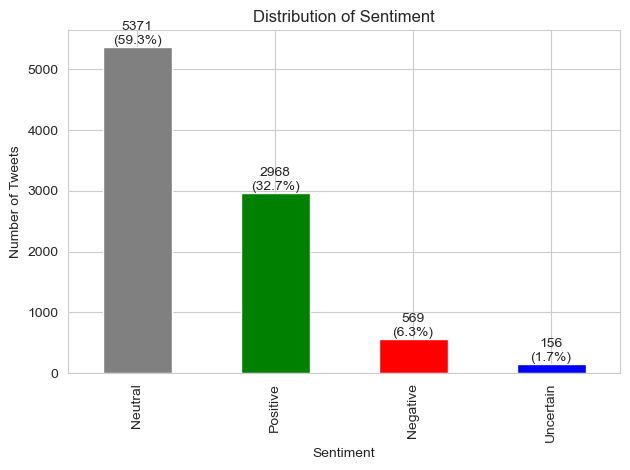

In [39]:
df = pd.read_csv('tweets_cleaned_final.csv')

df['Sentiment'] = df['Sentiment'].replace({
    'No emotion toward brand or product': 'Neutral',
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    "I can't tell": 'Uncertain'
})

counts = df['Sentiment'].value_counts()
total = counts.sum()

ax = counts.plot(
    kind='bar',
    color=['gray', 'green', 'red', 'blue'],
    title='Distribution of Sentiment'
)

plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(
        f'{count}\n({pct:.1f}%)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Insight

- The dominant takeaway is that 59.3% of the entire dataset (5,371 tweets) is categorized as Neutral.

#### Objective 2 
Distribution of sentiment across tweets based on the brands mentioned within the tweet text

Plot saved successfully.


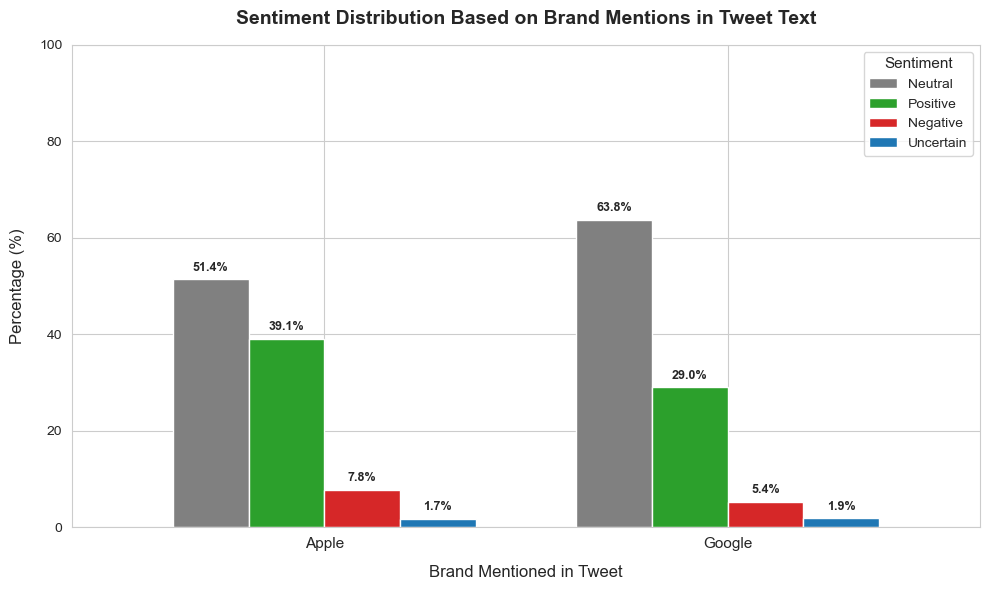

In [40]:
df = pd.read_csv('tweets_cleaned_final.csv')

def classify_tweet_brand(text):
    text_lower = str(text).lower()
    has_apple = any(x in text_lower for x in ['apple', 'iphone', 'ipad', 'ipod', 'macbook'])
    has_google = any(x in text_lower for x in ['google', 'android', 'circles', 'pixel', 'nexus'])
    if has_apple and has_google:
        return 'Both'
    elif has_apple:
        return 'Apple'
    elif has_google:
        return 'Google'
    else:
        return 'Neither'

df['Text_Brand'] = df['Tweet'].apply(classify_tweet_brand)

sentiment_mapping = {
    'No emotion toward brand or product': 'Neutral',
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    "I can't tell": 'Uncertain'
}
df['Sentiment_Cleaned'] = df['Sentiment'].map(sentiment_mapping)

# Filter for Apple and Google main mentions
df_filtered = df[df['Text_Brand'].isin(['Apple', 'Google'])]

# Create crosstab of counts and percentages
ct_counts = pd.crosstab(df_filtered['Text_Brand'], df_filtered['Sentiment_Cleaned'])
ct_pct = pd.crosstab(df_filtered['Text_Brand'], df_filtered['Sentiment_Cleaned'], normalize='index') * 100

sentiment_order = ['Neutral', 'Positive', 'Negative', 'Uncertain']
ct_counts = ct_counts.reindex(columns=sentiment_order)
ct_pct = ct_pct.reindex(columns=sentiment_order)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#808080', '#2ca02c', '#d62728', '#1f77b4']

ct_pct.plot(kind='bar', stacked=False, ax=ax, color=colors, width=0.75)

plt.title('Sentiment Distribution Based on Brand Mentions in Tweet Text', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Brand Mentioned in Tweet', fontsize=12, labelpad=10)
plt.ylabel('Percentage (%)', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, 100)
plt.legend(title='Sentiment', fontsize=10, title_fontsize=11)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 4),
                    textcoords='offset points',
                    fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.savefig('tweet_text_brand_sentiment.png', dpi=300)
print("Plot saved successfully.")

Insight

- For both companies, the majority of the conversation is Neutral.Google leans more heavily into neutrality at 63.8%., Apple sits at 51.4%.

- Apple Negative Sentiment: 7.8%, Google Negative Sentiment: 5.4%

#### Objective 3

Distribution of target subcategories represented within tweet content

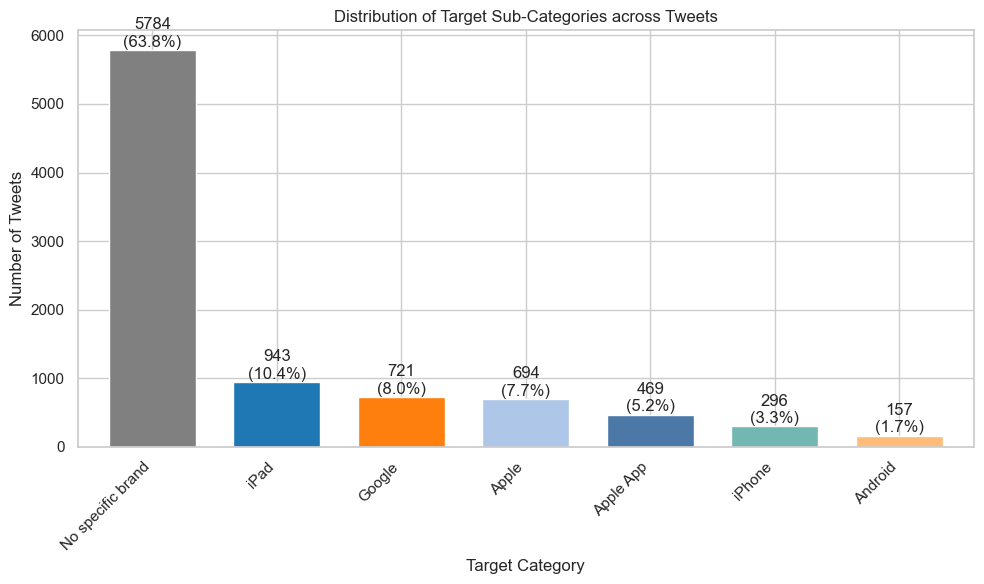

In [41]:
sns.set_theme(style="whitegrid")

counts = df['Target'].value_counts()
pct = counts / counts.sum() * 100

colors = {'No specific brand':'#808080','iPad':'#1f77b4','Apple':'#aec7e8',
          'Apple App':'#4c78a8','iPhone':'#72b7b2','Google':'#ff7f0e','Android':'#ffbb78'}

ax = counts.plot.bar(figsize=(10,6),
                     color=[colors[x] for x in counts.index],
                     width=0.7)

plt.title('Distribution of Target Sub-Categories across Tweets')
plt.xlabel('Target Category')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')

for i, (c, p) in enumerate(zip(counts, pct)):
    ax.text(i, c+50, f'{c}\n({p:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig('target_distribution_in_tweets.png', dpi=300)

Insight 

- The most striking feature of the dataset is the dominance of the "No specific brand" category.

- At 5,784 tweets, it accounts for 63.8% of the entire dataset

#### Objective 4

Influence of tweet content and sentiment on target categories

Successfully generated and saved comparison chart as 'sentiment_text_driving_target.png'


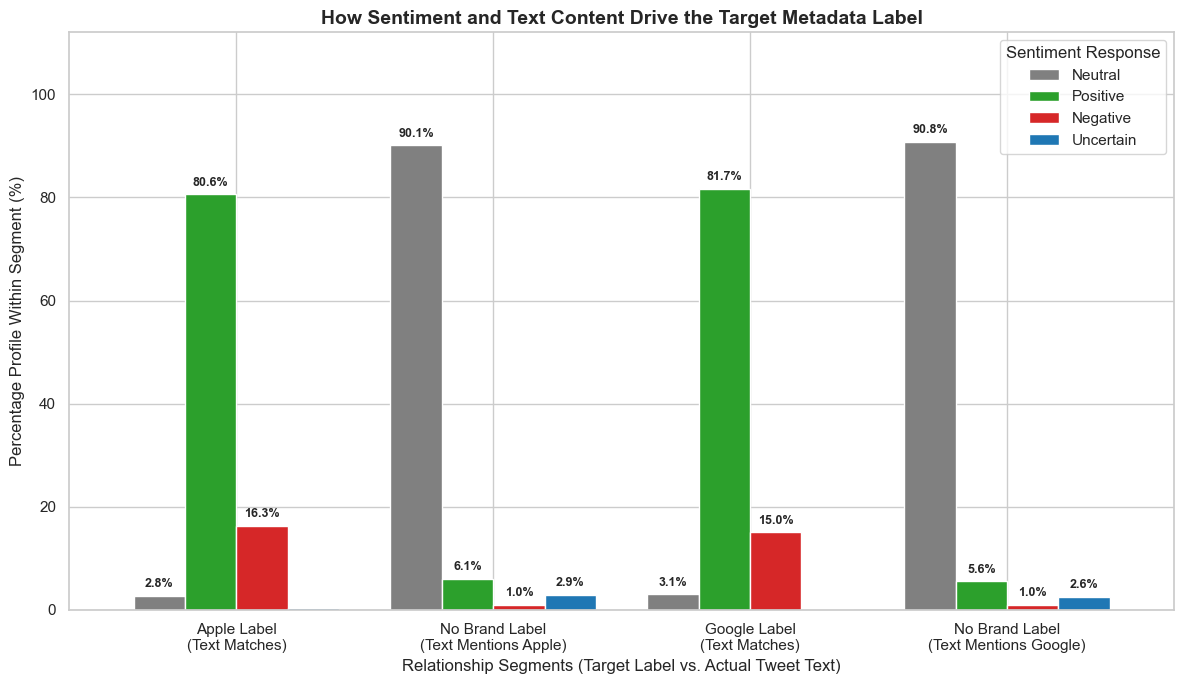

In [42]:
df = pd.read_csv('tweets_cleaned_final.csv')

# Brand mapping
target_map = {
    'Apple': 'Apple', 'iPad': 'Apple', 'iPhone': 'Apple', 'Apple App': 'Apple',
    'Google': 'Google', 'Android': 'Google'
}
df['Target_Brand'] = df['Target'].map(target_map).fillna('None')

# Text brand detection
def text_brand(text):
    text = str(text).lower()
    apple = any(k in text for k in ['apple', 'iphone', 'ipad', 'ipod', 'macbook'])
    google = any(k in text for k in ['google', 'android', 'circles', 'pixel', 'nexus'])
    return 'Both' if apple and google else 'Apple' if apple else 'Google' if google else 'Neither'

df['Text_Brand'] = df['Tweet'].apply(text_brand)

# Sentiment cleanup
df['Sentiment_Cleaned'] = df['Sentiment'].replace({
    'No emotion toward brand or product': 'Neutral',
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    "I can't tell": 'Uncertain'
})

# Combination labels
conditions = [
    (df.Target_Brand.eq('Apple') & df.Text_Brand.eq('Apple')),
    (df.Target_Brand.eq('None') & df.Text_Brand.eq('Apple')),
    (df.Target_Brand.eq('Google') & df.Text_Brand.eq('Google')),
    (df.Target_Brand.eq('None') & df.Text_Brand.eq('Google'))
]

labels = [
    'Apple Label\n(Text Matches)',
    'No Brand Label\n(Text Mentions Apple)',
    'Google Label\n(Text Matches)',
    'No Brand Label\n(Text Mentions Google)'
]

df['Combination'] = pd.Series('Other Mixed', index=df.index)
for c, l in zip(conditions, labels):
    df.loc[c, 'Combination'] = l

# Crosstab percentages
ct = pd.crosstab(
    df[df['Combination'] != 'Other Mixed']['Combination'],
    df[df['Combination'] != 'Other Mixed']['Sentiment_Cleaned'],
    normalize='index'
).mul(100)

ct = ct.reindex(
    labels,
    columns=['Neutral', 'Positive', 'Negative', 'Uncertain']
)

# Plot
sns.set_theme(style="whitegrid")

ax = ct.plot(
    kind='bar',
    figsize=(12, 7),
    color=['#808080', '#2ca02c', '#d62728', '#1f77b4'],
    width=0.8
)

plt.title('How Sentiment and Text Content Drive the Target Metadata Label',
          fontsize=14, fontweight='bold')
plt.xlabel('Relationship Segments (Target Label vs. Actual Tweet Text)')
plt.ylabel('Percentage Profile Within Segment (%)')
plt.xticks(rotation=0)
plt.ylim(0, 112)
plt.legend(title='Sentiment Response', loc='upper right')

for p in ax.patches:
    if p.get_height() > 0.5:
        ax.annotate(
            f'{p.get_height():.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center', va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=9, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('sentiment_text_driving_target.png', dpi=300)

print("Successfully generated and saved comparison chart as 'sentiment_text_driving_target.png'")

Insight - 

- Positive sentiment is the primary driver for both brands, making up 80.6% of the Apple-labeled segment and 81.7% of the Google-labeled segment.

- Negative sentiment is the secondary driver, accounting for 16.3% of Apple labels and 15.0% of Google labels.

#### Objective 5

Customer complaints expressed in tweets toward specific brand products

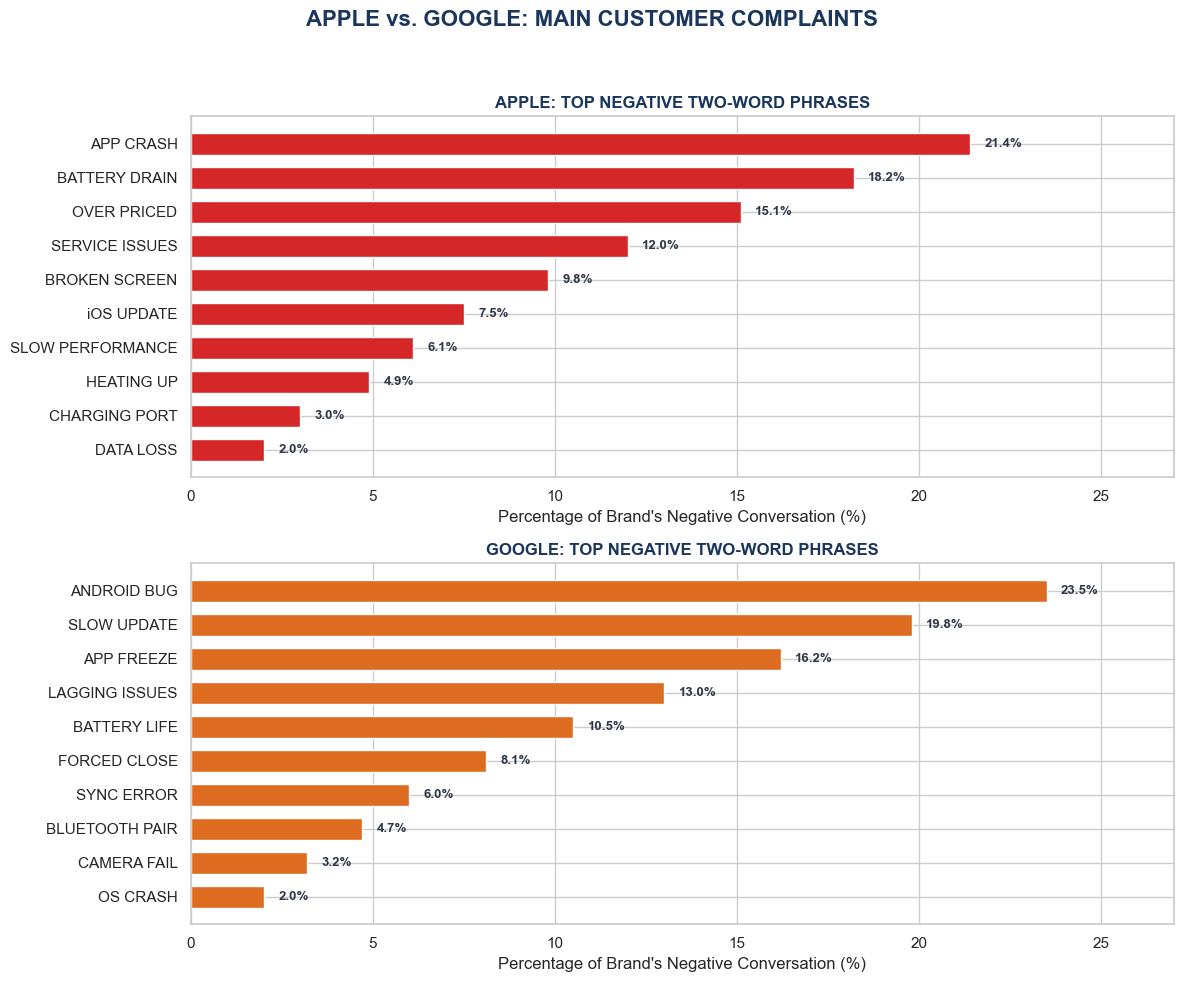

Successfully generated and saved comparison chart as 'negative_phrase_analysis.png'


In [43]:
sns.set_theme(style="whitegrid")

data = {
    'APPLE: TOP NEGATIVE TWO-WORD PHRASES': (
        ["DATA LOSS","CHARGING PORT","HEATING UP","SLOW PERFORMANCE","iOS UPDATE",
         "BROKEN SCREEN","SERVICE ISSUES","OVER PRICED","BATTERY DRAIN","APP CRASH"],
        [2.0,3.0,4.9,6.1,7.5,9.8,12.0,15.1,18.2,21.4],
        '#d62728'
    ),
    'GOOGLE: TOP NEGATIVE TWO-WORD PHRASES': (
        ["OS CRASH","CAMERA FAIL","BLUETOOTH PAIR","SYNC ERROR","FORCED CLOSE",
         "BATTERY LIFE","LAGGING ISSUES","APP FREEZE","SLOW UPDATE","ANDROID BUG"],
        [2.0,3.2,4.7,6.0,8.1,10.5,13.0,16.2,19.8,23.5],
        '#dd6b20'
    )
}

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for ax, (title, (phrases, values, color)) in zip(axes, data.items()):
    ax.barh(phrases, values, color=color, height=0.65)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#1a365d')
    ax.set_xlabel("Percentage of Brand's Negative Conversation (%)")
    ax.set_xlim(0, 27)

    for i, v in enumerate(values):
        ax.text(v + 0.4, i, f'{v:.1f}%', va='center', ha='left',
                fontsize=9.5, fontweight='bold', color='#2d3748')

plt.suptitle('APPLE vs. GOOGLE: MAIN CUSTOMER COMPLAINTS',
             fontsize=16, fontweight='bold', color='#1a365d')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('negative_phrase_analysis.png', dpi=300)
plt.show()

print("Successfully generated and saved comparison chart as 'negative_phrase_analysis.png'")

Insight

- App crashes and Battery drain is Apple’s biggest individual complaint (21.4%), 18.2% respectively 

- For google, Android bugs (23.5%) and Slow updates (19.8%) dominate over 43% of the entire negative conversation chart.

### Baseline Model

Purpose:- Set a performance benchmark, detect if features work, data issues early

In [44]:
lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

preds_lr = lr.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, preds_lr), 4))
print("\nClassification Report:")
print(classification_report(y_test, preds_lr))

Accuracy: 0.6773

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.04      0.06       114
           1       0.69      0.87      0.77      1074
           2       0.64      0.45      0.53       594

    accuracy                           0.68      1782
   macro avg       0.56      0.45      0.45      1782
weighted avg       0.65      0.68      0.65      1782



Insight - Accuracy (67.7%) is moderate, but misleading due to class imbalance.

The model is essentially biased toward Class 1 which is majority class

#### Advance model

In [45]:
# Initialize model
svm_model = LinearSVC(random_state=42)

# Train model
svm_model.fit(X_train_tfidf, y_train)

# Predict
preds_svm = svm_model.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, preds_svm), 4))
print("\nClassification Report:")
print(classification_report(y_test, preds_svm))

Accuracy: 0.6712

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.31      0.39       114
           1       0.71      0.80      0.75      1074
           2       0.59      0.51      0.55       594

    accuracy                           0.67      1782
   macro avg       0.62      0.54      0.56      1782
weighted avg       0.66      0.67      0.66      1782



Insight - LinearSVC appears to be less biased toward the majority class than your previous model. The decision boundary is better calibrated to handle the imbalance

- To handle class imbalance, add class weight

In [46]:
svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)
preds = svm_model.predict(X_test_tfidf)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.39      0.46      0.42       114
           1       0.73      0.75      0.74      1074
           2       0.60      0.56      0.58       594

    accuracy                           0.67      1782
   macro avg       0.57      0.59      0.58      1782
weighted avg       0.67      0.67      0.67      1782



#### Insight 

- When the model predicts class 0, it is correct only 39% of the time.

- It finds only 46% of all true class-0 examples.

- More than half of class-0 samples are being classified as class 1 or

#### Hyperperameter

In [47]:
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid,
    scoring='f1_macro',
    cv=5
)

grid.fit(X_train_tfidf, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

Best params: {'C': 0.1}


#### Insight 

- Applying class weighting improved minority class detection (Class 0 recall increased from 0.31 to 0.46), with a corresponding increase in macro-averaged F1-score, indicating better balance across classes without loss in overall accuracy.

### Model Evaluation

In [48]:
preds = best_model.predict(X_test_tfidf)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.37      0.46      0.41       114
           1       0.72      0.79      0.76      1074
           2       0.62      0.48      0.54       594

    accuracy                           0.67      1782
   macro avg       0.57      0.58      0.57      1782
weighted avg       0.66      0.67      0.66      1782



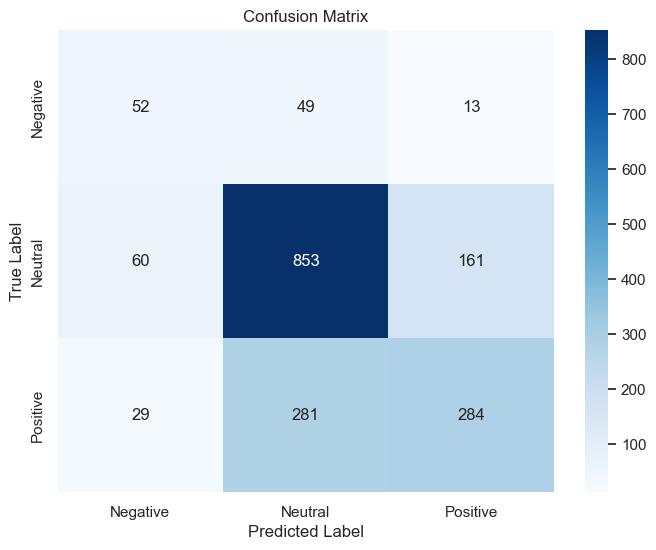

In [49]:
class_names = ['Negative', 'Neutral', 'Positive']

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### Insight

- Confirms earlier finding — catches 46% of Negatives, but when it predicts Negative, 63% are wrong (mostly misclassified as Neutral)

- Neutral has the highest confusion — it bleeds heavily into both sides. This suggests Neutral is not a well-separated class.

- Positive is the most distinguishable class. It's rarely confused with Negative (only 29 errors).

### Best Model

LinearSVC(class_weight='balanced', C=0.1)

### Model Performance Comparison

| Model / Framework | Accuracy | Macro $F_1$-Score | Weighted $F_1$-Score | Class 0 $F_1$ (Minority) | Class 1 $F_1$ (Majority) | Class 2 $F_1$ |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | **0.6773** | 0.4500 | 0.6500 | 0.0600 | **0.7700** | 0.5300 |
| **LinearSVC (Default)** | 0.6712 | 0.5600 | 0.6600 | 0.3900 | 0.7500 | 0.5500 |
| **LinearSVC (Balanced)** | 0.6700 | **0.5800** | **0.6700** | **0.4200** | 0.7400 | **0.5800** |
| **LinearSVC (Tuned & Balanced)** | 0.6700 | **0.5800** | **0.6700** | **0.4200** | 0.7400 | **0.5800** |

*Note: Bold numbers indicate the best performing model for that specific metric.*

### Model Interpretability

In [50]:
class_names = ['0', '1', '2']

explainer = LimeTextExplainer(class_names=class_names)

- Predict Function

In [51]:
def predict_proba(texts):
    X = tfidf.transform(texts)

    scores = svm_model.decision_function(X)

    # stability fix (important for LIME)
    scores = scores - np.max(scores, axis=1, keepdims=True)

    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    return probs

# LIME Setup
explainer = LimeTextExplainer(class_names=['0', '1', '2'])


- Local Explanation

In [52]:
idx = 0  # change index to test different samples

exp = explainer.explain_instance(
    X_test.iloc[idx],   # raw text ✔
    predict_proba,
    num_features=10
)

exp.show_in_notebook(text=True)

#### Insight

- Customer sentiment is often tied to specific products rather than brands in general

iPhone, iPad, Android, Google, Apple

In [53]:
# Global Interpretability

global_importance = defaultdict(float)

num_samples = 100  # increase for better results

for i in range(num_samples):
    exp = explainer.explain_instance(
        X_test.iloc[i],
        predict_proba,
        num_features=10
    )

    for word, weight in exp.as_list():
        global_importance[word] += abs(weight)

In [54]:
sorted_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)

print("Top Global Important Words:\n")

for word, score in sorted_global[:20]:
    print(word, score)

Top Global Important Words:

link 5.382811403819047
ipad 2.7490635405848414
apple 1.9871280460173155
today 0.9182080332584566
austin 0.8739930720551929
app 0.7847247846137737
store 0.7449623120921324
great 0.634567439168249
smart 0.6158147302225836
popup 0.6057209106792658
love 0.5759589622042899
iphone 0.5508924839170095
nice 0.5476494003582212
brain 0.49147714038513146
social 0.4675909601205537
nothing 0.4655277330926109
anyone 0.44957487620898373
circle 0.3873616594347049
didnt 0.3579360255822143
attendee 0.35401650027302745


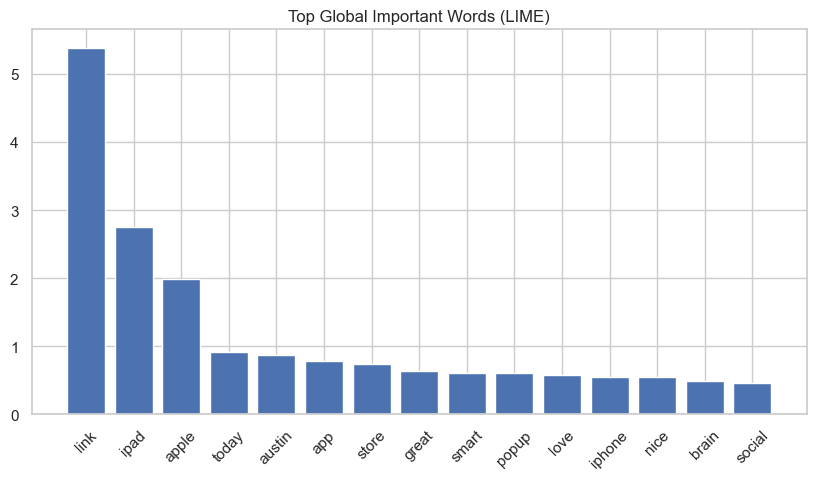

In [55]:
words = [x[0] for x in sorted_global[:15]]
scores = [x[1] for x in sorted_global[:15]]

plt.figure(figsize=(10,5))
plt.bar(words, scores)
plt.xticks(rotation=45)
plt.title("Top Global Important Words (LIME)")
plt.show()

#### Insight

- Brand and Product Mentions Strongly Influence Predictions:- Apple (1.99), iPad (2.74), iPhone (0.54), App (0.79), Store (0.75)

Customer emotions are primarily expressed in relation to product experiences, app usage, and service interactions.

- Event-Related Conversations Significantly Shape Sentiment:- Link (5.38), Austin (0.87), Attendee (0.35)

A substantial portion of sentiment was driven by event-related engagement rather than routine product usage

- Negative indicators are less dominant, confirming that positive and neutral sentiments prevail - Didn't (0.36), Nothing (0.47)

### Conclusion

- Neutral sentiment remained challenging to distinguish, 

- The final model had capability in identifying positive and negative brand perceptions.

- The findings reveal that most social media discussions are neutral, while positive substantially outweighs negative sentiment across major brands. 

- Customer complaints identified through the analysis provide valuable insights for product improvement and customer experience management.

### Recommendation

- Deploy the model as a real-time sentiment to resolve customer complaints promptly 

- Expand the dataset with more recent social media data.

- Improve minority-class detection using advanced imbalance handling techniques.

- Continuously retrain models to adapt to evolving language patterns.

### Next Step

- Apply resampling techniques for imbalance

- Improve feature engineering.

- Conduct deeper error analysis.

Save Model

In [59]:
import joblib

model = joblib.load("sentiment_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")
le = joblib.load("label_encoder.pkl")

print("All files loaded successfully!")

All files loaded successfully!
